In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)

1.Basics: estimator Api, datasets, train_test_split

In [26]:
from sklearn.datasets import load_iris

iris = load_iris()
x, y = iris.data, iris.target

print("x shape:", x.shape)          # (150 samples, 4 features)
print("y shape:", y.shape)
print("Features:", iris.feature_names)
print("Classes :", list(iris.target_names))

# Look at it as a DataFrame (easier to read)
df = pd.DataFrame(x, columns=iris.feature_names)
df["species"] = pd.Series(y).map(dict(enumerate(iris.target_names)))
df.head()

x shape: (150, 4)
y shape: (150,)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Train/ test split

In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", x_train.shape, "Test:", x_test.shape)
print("Class counts in train:", np.bincount(y_train))
print("Class counts in test:", np.bincount(y_test))

Train: (120, 4) Test: (30, 4)
Class counts in train: [40 40 40]
Class counts in test: [10 10 10]


THe 'fit->predict->score' pattern

In [28]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)   #1. create the model with settings(hyperparameters)
model.fit(x_train, y_train)                   #2. learn from training
preds = model.predict(x_test)                 #3. predict on unseen data

print("First 10 predictions:", preds[:10])
print("First 10 real labels:", y_test[:10])
print("Accuracy:", model.score(x_test, y_test))

First 10 predictions: [0 2 1 1 0 1 0 0 2 1]
First 10 real labels: [0 2 1 1 0 1 0 0 2 1]
Accuracy: 1.0


The 'transform' side of API 

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)      # learn mean/std from TRAIN and apply
x_test_s  = scaler.transform(x_test)           # only apply, never fit on test

print("Train mean after scaling:", x_train_s.mean(axis=0))         # ~0
print("Train std after  scaling:", x_train_s.std(axis=0))          # ~1
print("Learned means :", scaler.mean_)

Train mean after scaling: [-0. -0.  0.  0.]
Train std after  scaling: [1. 1. 1. 1.]
Learned means : [5.842 3.048 3.77  1.205]


2.Preprocessing: scaling, encoding, missing values, feature selection

In [30]:
data = pd.DataFrame({
    "age":    [25, 32, np.nan, 45, 29, 51, np.nan, 38],
    "salary": [30000, 52000, 41000, np.nan, 38000, 90000, 45000, 61000],
    "city":   ["Pune", "Mumbai", "Pune", "Delhi", "Mumbai", "Delhi", "Pune", "Mumbai"],
    "bought": ["no", "yes", "no", "yes", "no", "yes", "no", "yes"],
})

print(data)
print("\nMissing values per column:\n", data.isna().sum())

    age   salary    city bought
0  25.0  30000.0    Pune     no
1  32.0  52000.0  Mumbai    yes
2   NaN  41000.0    Pune     no
3  45.0      NaN   Delhi    yes
4  29.0  38000.0  Mumbai     no
5  51.0  90000.0   Delhi    yes
6   NaN  45000.0    Pune     no
7  38.0  61000.0  Mumbai    yes

Missing values per column:
 age       2
salary    1
city      0
bought    0
dtype: int64


2.1 Missing values: 'SimpleImputer'

In [31]:
from sklearn.impute import SimpleImputer

num_cols = ["age", "salary"]
imputer = SimpleImputer(strategy="median")
data[num_cols] = imputer.fit_transform(data[num_cols])
print(data)
print("\nstill missing:", data.isna().sum().sum())

    age   salary    city bought
0  25.0  30000.0    Pune     no
1  32.0  52000.0  Mumbai    yes
2  35.0  41000.0    Pune     no
3  45.0  45000.0   Delhi    yes
4  29.0  38000.0  Mumbai     no
5  51.0  90000.0   Delhi    yes
6  35.0  45000.0    Pune     no
7  38.0  61000.0  Mumbai    yes

still missing: 0


2.2 Scaling: 'StandardDcalar vs MinMaxScalar'

In [32]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

std_scaled = StandardScaler().fit_transform(data[num_cols])
mm_scaled = MinMaxScaler().fit_transform(data[num_cols])

compare = pd.DataFrame({
    "age (raw)": data["age"], "age (standard)": std_scaled[:, 0], "age (minmax)": mm_scaled[:, 0],
})
compare

,age (raw),age (standard),age (minmax)
0,25.0,-1.427,0.000
1,32.0,-0.539,0.269
2,35.0,-0.159,0.385
3,45.0,1.110,0.769
4,29.0,-0.919,0.154
5,51.0,1.870,1.000
6,35.0,-0.159,0.385
7,38.0,0.222,0.500


2.3 Encoding categories

'OneHotEncoder' and 'LabelEncoder'

In [33]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# one-hot for the feature 'city'
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")   #ignore = unseen city wont crash
city_encoded = ohe.fit_transform(data[["city"]])
city_df = pd.DataFrame(city_encoded, columns=ohe.get_feature_names_out(["city"]))
print(city_df.head())

# Label encoding for the target
le = LabelEncoder()
y_enc = le.fit_transform(data["bought"])
print("\nClasses:", le.classes_, "->", y_enc)
print("Back to text:", le.inverse_transform(y_enc[:3]))

   city_Delhi  city_Mumbai  city_Pune
0         0.0          0.0        1.0
1         0.0          1.0        0.0
2         0.0          0.0        1.0
3         1.0          0.0        0.0
4         0.0          1.0        0.0

Classes: ['no' 'yes'] -> [0 1 0 1 0 1 0 1]
Back to text: ['no' 'yes' 'no']


2.4 Feature selection

In [34]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
xc, yc = cancer.data, cancer.target
print("Original features:", xc.shape[1])

#a) remove near-constant feature
vt = VarianceThreshold(threshold=0.01)
print("After VarianceThreshold:", vt.fit_transform(xc).shape[1])

#b) keep the 5 best features by ANOVA F-score
skb = SelectKBest(score_func=f_classif, k=5)
xc_best = skb.fit_transform(xc, yc)
best_names = np.array(cancer.feature_names)[skb.get_support()]
print("Top 5 features:", list(best_names))

Original features: 30
After VarianceThreshold: 14
Top 5 features: [np.str_('mean perimeter'), np.str_('mean concave points'), np.str_('worst radius'), np.str_('worst perimeter'), np.str_('worst concave points')]


3. Regression(predicting a number)




In [35]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

diabetes = load_diabetes()

xd = diabetes.data
yd = diabetes.target

xd_tr, xd_te, yd_tr, yd_te = train_test_split(xd, yd, test_size=0.2, random_state =42)

#diabetes feature are already scaled. on your data, scale first for Ridge/Lasso.

In [36]:
poly = PolynomialFeatures(degree=2, include_bias=False)
xd_tr_poly = poly.fit_transform(xd_tr)
xd_te_poly = poly.transform(xd_te)

results = []
def evaluate(name, model, xtr, xte):
    model.fit(xtr, yd_tr)
    pred = model.predict(xte)
    results.append({
        "Model": name,
        "R2": r2_score(yd_te, pred),
        "RMSE": np.sqrt(mean_squared_error(yd_te, pred)),
    })
    return model

evaluate("Linear",         LinearRegression(),                  xd_tr, xd_te)
evaluate("Ridge(alpha=1)", Ridge(alpha=0.1),                    xd_tr, xd_te)
lasso = evaluate("Lasso(alpha=0.1)", Lasso(alpha=0.1),          xd_tr, xd_te)
evaluate("Polynomial (deg 2)",       LinearRegression(),        xd_tr_poly, xd_te_poly)
evaluate("Decision Tree",         DecisionTreeRegressor(max_depth=4, random_state=42),  xd_tr, xd_te)
evaluate("Random Forest",         RandomForestRegressor(n_estimators=200, random_state=42), xd_tr, xd_te)

pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)

,Model,R2,RMSE
0,Lasso(alpha=0.1),0.472,52.898
1,Ridge(alpha=1),0.461,53.446
2,Linear,0.453,53.853
3,Random Forest,0.440,54.461
4,Polynomial (deg 2),0.416,55.642
5,Decision Tree,0.326,59.741


In [37]:
# Lasso sets unimportant feature weights to exactly 0 -> built-in feature selection
names = load_diabetes().feature_names
print(pd.Series(lasso.coef_, index=names).round(1))

age      0.0
sex   -152.7
bmi    552.7
bp     303.4
s1     -81.4
s2      -0.0
s3    -229.3
s4       0.0
s5     447.9
s6      29.6
dtype: float64


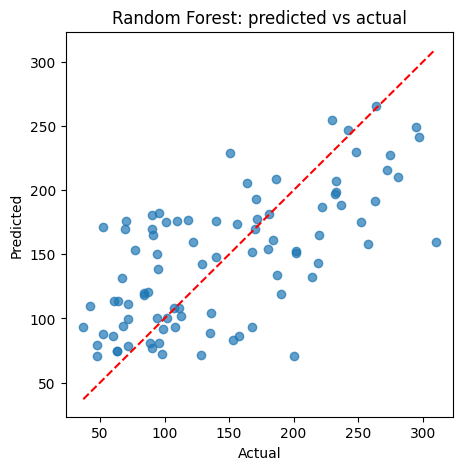

In [38]:
# Predicted vs actual for the Random Forest (points near the red line = good)
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(xd_tr, yd_tr)
pred = rf.predict(xd_te)

plt.figure(figsize=(5, 5))
plt.scatter(yd_te, pred, alpha=0.7)
lims = [yd_te.min(), yd_te.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: predicted vs actual")
plt.show()

Classification (predicting a category)

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

xtr, xte, ytr, yte = train_test_split(xc, yc, test_size=0.2, random_state=42, stratify=yc)

sc = StandardScaler()
xtr_s = sc.fit_transform(xtr)
xte_s = sc.transform(xte)

# (model, needs_scaling)
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), True),
    "KNN (k=5)":           (KNeighborsClassifier(n_neighbors=5), True),
    "SVM (RBF)":           (SVC(kernel="rbf", C=1.0), True),
    "Decision Tree":       (DecisionTreeClassifier(max_depth=5, random_state=42), False),
    "Random Forest":       (RandomForestClassifier(n_estimators=200, random_state=42), False),
    "Naive Bayes":         (GaussianNB(), False),
}

rows = []
for name, (m, scaled) in models.items():
    a, b = (xtr_s, xte_s) if scaled else (xtr, xte)
    m.fit(a, ytr)
    rows.append({"model":name,
                 "Train acc": accuracy_score(ytr, m.predict(a)),
                 "Test acc": accuracy_score(yte, m.predict(b))})



pd.DataFrame(rows).sort_values("Test acc", ascending=False).reset_index(drop=True)    

,model,Train acc,Test acc
0,Logistic Regression,0.989,0.982
1,SVM (RBF),0.982,0.982
2,KNN (k=5),0.974,0.956
3,Random Forest,1.000,0.956
4,Naive Bayes,0.941,0.939
5,Decision Tree,0.993,0.921


Probability of [maligant, benign] for 3 patients:
 [[1.    0.   ]
 [0.    1.   ]
 [0.994 0.006]]


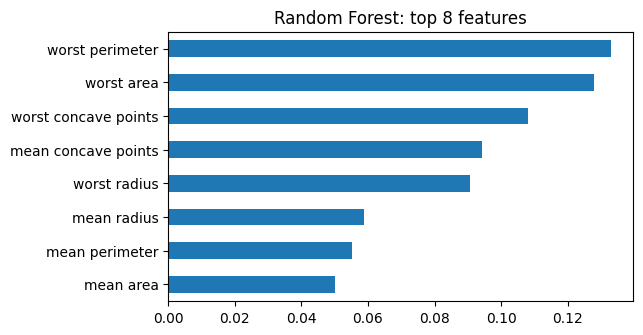

In [40]:
# Probabilities and feature importance
lr = LogisticRegression(max_iter=1000).fit(xtr_s, ytr)
proba = lr.predict_proba(xte_s[:3])
print("Probability of [maligant, benign] for 3 patients:\n", proba.round(3))

rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(xtr, ytr)
imp = pd.Series(rf.feature_importances_, index=cancer.feature_names).sort_values(ascending=False).head(8)
imp.sort_values().plot(kind="barh", figsize=(6, 3.5), title="Random Forest: top 8 features")
plt.show()

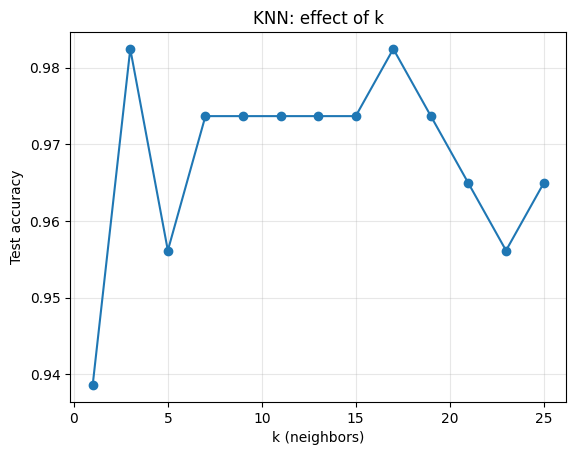

In [41]:
# KNN: how does the choice of k change accuracy?
ks = range(1, 26, 2)
accs = [KNeighborsClassifier(n_neighbors=k).fit(xtr_s, ytr).score(xte_s, yte) for k in ks]

plt.plot(list(ks), accs, marker="o")
plt.xlabel("k (neighbors)")
plt.ylabel("Test accuracy")
plt.title("KNN: effect of k")
plt.grid(alpha=0.3)
plt.show()

5. Clustering(unsupervised: no 'y', find groups)

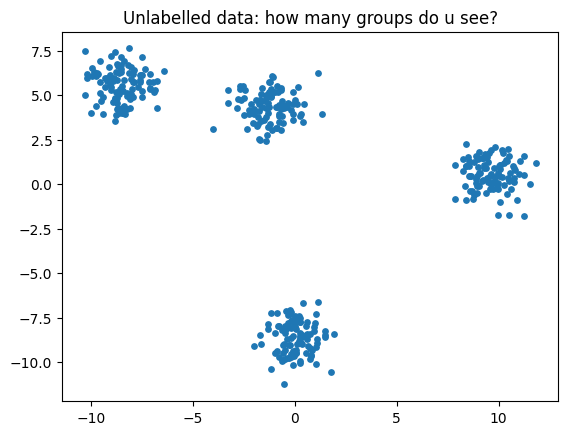

In [42]:
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

xb, _ = make_blobs(n_samples=400, centers=4, cluster_std=0.9, random_state=7)

plt.scatter(xb[:, 0], xb[:, 1], s=15)
plt.title("Unlabelled data: how many groups do u see?")
plt.show()

5.1 K-Means: choosing 'k' with elbow method and silhouette score 

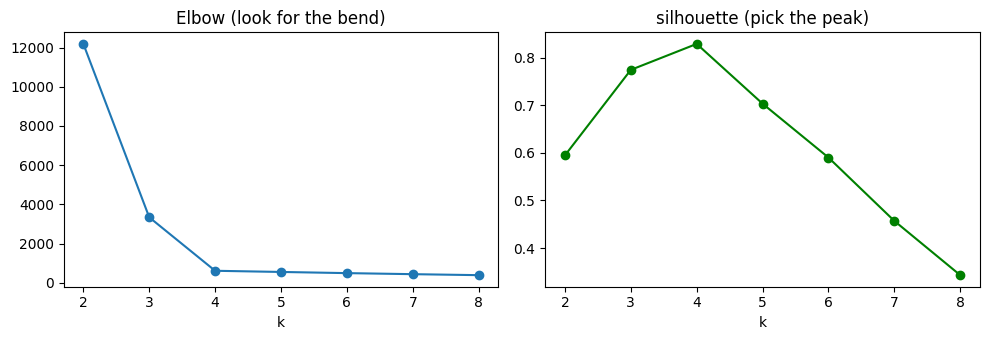

In [43]:
inertias, sils = [], []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(xb)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(xb, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(K, inertias, marker="o")
ax[0].set_title("Elbow (look for the bend)")
ax[0].set_xlabel("k")
ax[1].plot(K, sils, marker="o", color = "green")
ax[1].set_title("silhouette (pick the peak)")
ax[1].set_xlabel("k")
plt.tight_layout()
plt.show()    

5.2 DBSCAN vs KMeans on non-round shapes

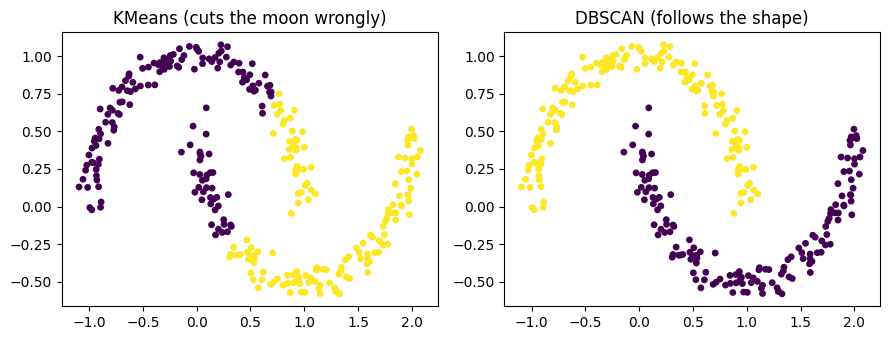

DBSCAN clusture found: 2 | noise points: 0


In [44]:
xm, _ = make_moons(n_samples=300, noise=0.06, random_state=1)

km_labels = KMeans(n_clusters=2, n_init=10, random_state=1).fit_predict(xm)
db_labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(xm)

fig, ax = plt.subplots(1,2, figsize=(9, 3.5))
ax[0].scatter(xm[:, 0], xm[:, 1], c=km_labels, s=15)
ax[0].set_title("KMeans (cuts the moon wrongly)")
ax[1].scatter(xm[:, 0], xm[:, 1], c=db_labels, s=15)
ax[1].set_title("DBSCAN (follows the shape)")
plt.tight_layout()
plt.show()
print("DBSCAN clusture found:", len(set(db_labels) - {-1}), "| noise points:", (db_labels == -1).sum())

5.3 Hierarchical (Agglomerative clustering)

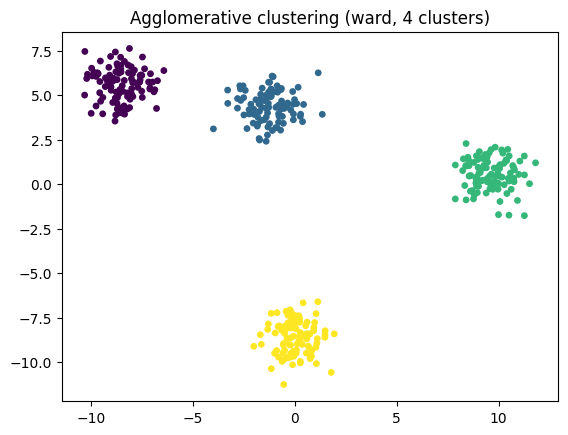

Silhouette KMeans: 0.343 | Agglomerative: 0.829


In [45]:
agg = AgglomerativeClustering(n_clusters=4, linkage="ward").fit(xb)
plt.scatter(xb[:, 0], xb[:, 1], c=agg.labels_, s=15, cmap="viridis")
plt.title("Agglomerative clustering (ward, 4 clusters)")
plt.show()
print("Silhouette KMeans:", round(silhouette_score(xb, km.labels_), 3),
      "| Agglomerative:", round(silhouette_score(xb, agg.labels_), 3))

6.Dimentionality Reduction: PCA

Variance kept by PC1, PC2: [0.443 0.19 ]
Total kept: 0.632


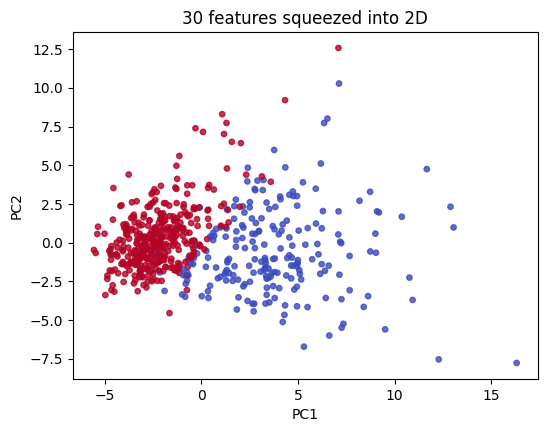

In [46]:
from sklearn.decomposition import PCA

# Cancer data: 30 features -> 2 for plotting
xc_scaled = StandardScaler().fit_transform(xc)
pca2 = PCA(n_components=2)
xc_2d = pca2.fit_transform(xc_scaled)

print("Variance kept by PC1, PC2:", pca2.explained_variance_ratio_.round(3))
print("Total kept:", pca2.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(6, 4.5))
plt.scatter(xc_2d[:, 0], xc_2d[:, 1], c=yc, cmap="coolwarm", s=15, alpha=0.8)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("30 features squeezed into 2D")
plt.show()

How many components do we need? keep ~95% of the variance

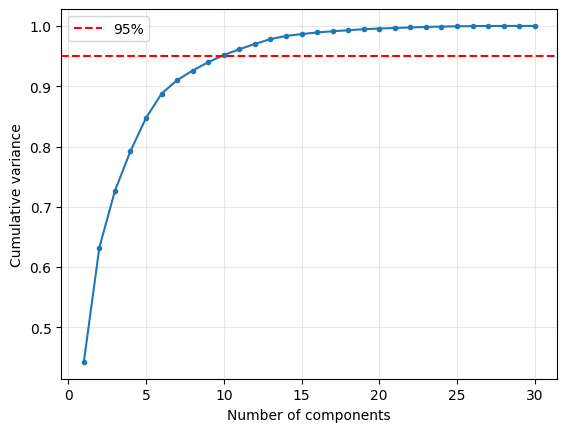

Features: 30 -> 10 (keeps 95% of information)


In [47]:
pca_full = PCA().fit(xc_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(cum) + 1), cum, marker="o", ms=3)
plt.axhline(0.95, color="r", ls="--", label="95%")
plt.xlabel("Number of components"); plt.ylabel("Cumulative variance"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Shortcut: give PCA a float and it picks the number itself
pca95 = PCA(n_components=0.95)
Xc_95 = pca95.fit_transform(xc_scaled)
print(f"Features: 30 -> {pca95.n_components_} (keeps 95% of information)")

does PCA hurt accuracy ? caompare a model om al;l features vs PCA features

In [48]:
xtr, xte, ytr, yte = train_test_split(xc, yc, test_size=0.2, random_state=42, stratify=yc)
sc = StandardScaler().fit(xtr)
xtr_s, xte_s = sc.transform(xtr), sc.transform(xte)

pca = PCA(n_components=0.95).fit(xtr_s)          # fit on TRAIN only
xtr_p, xte_p = pca.transform(xtr_s), pca.transform(xte_s)

full = LogisticRegression(max_iter=1000).fit(xtr_s, ytr)
red  = LogisticRegression(max_iter=1000).fit(xtr_p, ytr)
print(f"All 30 features : {full.score(xte_s, yte):.3f}")
print(f"PCA ({pca.n_components_} comps)   : {red.score(xte_p, yte):.3f}")

All 30 features : 0.982
PCA (10 comps)   : 0.974
